Original random line was about:
y = 1.3052331574958287 x + 1.5598375844802292 + random noise

part A
Least Squares line:
m = 1.341336738970611
b = 2.056202863423242

Cubic polyfit coefficients:
[-0.45279038  0.81642273  0.93377466  2.10081186]

Least Squares Metrics:
MSE = 0.07006556928312281
R^2 = 0.6857993106547359

Cubic Polyfit Metrics:
MSE = 0.06987912149851534
R^2 = 0.6866354135088188

Better fit in Part A: Cubic Polyfit



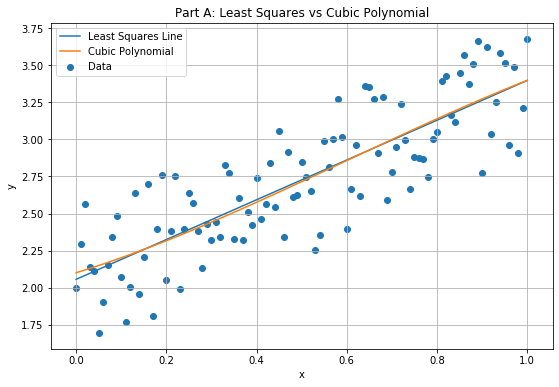

part B
Going up from cubic:

Degree 3 -> MSE = 0.06987912149851534  R^2 = 0.6866354135088188
Degree 4 -> MSE = 0.06986838543568745  R^2 = 0.6866835581021746
Degree 5 -> MSE = 0.06922499355203089  R^2 = 0.6895687722727348
Degree 6 -> MSE = 0.06922490265389072  R^2 = 0.6895691798946038
Degree 7 -> MSE = 0.06880105577728436  R^2 = 0.6914698706642517
Degree 8 -> MSE = 0.06828001501500437  R^2 = 0.6938064158227422
Degree 9 -> MSE = 0.06616532344952786  R^2 = 0.7032894979474368
Degree 10 -> MSE = 0.06502616832861245  R^2 = 0.7083979032301584

Going down from cubic:

Degree 3 -> MSE = 0.06987912149851534  R^2 = 0.6866354135088188
Degree 2 -> MSE = 0.06995674055302609  R^2 = 0.686287340115808
Degree 1 -> MSE = 0.07006556928312281  R^2 = 0.6857993106547359

Usual idea:
- lower degree can underfit
- higher degree can overfit
- low MSE and high R^2 are better, but use both together



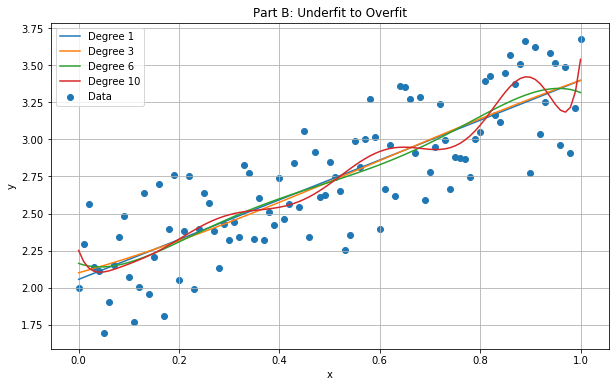

part C
Vandermonde cubic coefficients:
[ 2.10081186  0.93377466  0.81642273 -0.45279038]

Vandermonde Metrics:
MSE = 0.06987912149851536
R^2 = 0.6866354135088187

Compare Part C to cubic polyfit from part A:
Polyfit cubic MSE = 0.06987912149851534
Polyfit cubic R^2 = 0.6866354135088188
Vandermonde cubic MSE = 0.06987912149851536
Vandermonde cubic R^2 = 0.6866354135088187



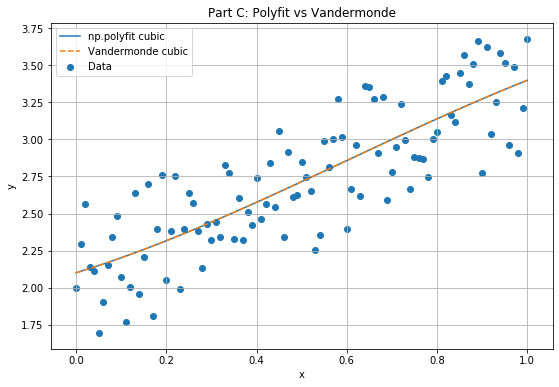

My notes:
Part A compared linear least squares to a cubic polynomial.
Part B started at degree 3, then moved up and down by 1 degree.
Part C used a Vandermonde matrix on the same data as Part A.
For all parts, I used MSE and R^2 to evaluate the fit.


In [4]:
import numpy as np
import matplotlib.pyplot as plt


def my_least_squares(x, y):
    # this is my linear least squares fit
    # line is y = mx + b

    n = len(x)

    sum_x = np.sum(x)
    sum_y = np.sum(y)
    sum_xy = np.sum(x * y)
    sum_x2 = np.sum(x ** 2)

    m = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x ** 2)
    b = (sum_y - m * sum_x) / n

    return m, b


def predict_line(x, m, b):
    # just plugging x into y = mx + b
    return m * x + b


def mse(y_true, y_pred):
    # mean squared error
    return np.mean((y_true - y_pred) ** 2)


def r_squared(y_true, y_pred):
    # R^2 = 1 - SSres / SStot
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)


def create_vandermonde_matrix(x, degree):
    # making the matrix 
    # increasing=True keeps it in that order
    return np.vander(x, N=degree + 1, increasing=True)


def vandermonde_fit(x, y, degree):
    # V a = y
    # then solve with least squares style linear algebra

    V = create_vandermonde_matrix(x, degree)

    # normal equation pieces
    VT_V = np.dot(V.T, V)
    VT_y = np.dot(V.T, y)

    # solve for the coefficient vector a
    coeffs = np.linalg.solve(VT_V, VT_y)

    # predicted y values
    y_pred = np.dot(V, coeffs)

    return coeffs, y_pred


def print_metrics(name, y_true, y_pred):
    # helps me print cleaner
    mse_val = mse(y_true, y_pred)
    r2_val = r_squared(y_true, y_pred)

    print(name)
    print("MSE =", mse_val)
    print("R^2 =", r2_val)
    print()

    return mse_val, r2_val


# make the same kind of random x and y data as before (learned this in coe332 or this class but is cool)
np.random.seed(7)

# using x from 0 to 1 with step 0.01 like the old challenge
x = np.arange(0, 1.01, 0.01)

# random linear function with random error between 0 and 1
m_true = np.random.uniform(1, 5)
b_true = np.random.uniform(0, 2)
noise = np.random.uniform(0, 1, len(x))

y = m_true * x + b_true + noise

# looked up this noise thingy
print("Original random line was about:")
print("y =", m_true, "x +", b_true, "+ random noise")
print()


# part A
# Linear Least Squares vs Polynomial fit
# start with cubic polynomial

print("part A")

# linear least squares
m_ls, b_ls = my_least_squares(x, y)
y_ls = predict_line(x, m_ls, b_ls)

# cubic polynomial using polyfit
degree_a = 3
coeffs_poly3 = np.polyfit(x, y, degree_a)
poly3 = np.poly1d(coeffs_poly3)
y_poly3 = poly3(x)

print("Least Squares line:")
print("m =", m_ls)
print("b =", b_ls)
print()

print("Cubic polyfit coefficients:")
print(coeffs_poly3)
print()

mse_ls, r2_ls = print_metrics("Least Squares Metrics:", y, y_ls)
mse_poly3, r2_poly3 = print_metrics("Cubic Polyfit Metrics:", y, y_poly3)

# decide better fit using both metrics together
if mse_poly3 < mse_ls and r2_poly3 > r2_ls:
    print("Better fit in Part A: Cubic Polyfit")
elif mse_ls < mse_poly3 and r2_ls > r2_poly3:
    print("Better fit in Part A: Linear Least Squares")
else:
    print("Part A result: metrics are mixed, so compare MSE and R^2 together")
print()

# plot the line and the polynomial
plt.figure(figsize=(9, 6))
plt.scatter(x, y, label="Data")
plt.plot(x, y_ls, label="Least Squares Line")
plt.plot(x, y_poly3, label="Cubic Polynomial")
plt.title("Part A: Least Squares vs Cubic Polynomial")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()


# part B
# start with cubic
# crank degree up until it blatantly overfits
# crank degree down until it underfits

print("part B")

print("Going up from cubic:")
print()

up_results = []

for deg in range(3, 11):
    coeffs = np.polyfit(x, y, deg)
    poly = np.poly1d(coeffs)
    y_pred = poly(x)

    mse_val = mse(y, y_pred)
    r2_val = r_squared(y, y_pred)

    up_results.append((deg, mse_val, r2_val))
    print("Degree", deg, "-> MSE =", mse_val, " R^2 =", r2_val)

print()
print("Going down from cubic:")
print()

down_results = []

for deg in range(3, 0, -1):
    coeffs = np.polyfit(x, y, deg)
    poly = np.poly1d(coeffs)
    y_pred = poly(x)

    mse_val = mse(y, y_pred)
    r2_val = r_squared(y, y_pred)

    down_results.append((deg, mse_val, r2_val))
    print("Degree", deg, "-> MSE =", mse_val, " R^2 =", r2_val)

print()
print("Usual idea:")
print("- lower degree can underfit")
print("- higher degree can overfit")
print("- low MSE and high R^2 are better, but use both together")
print()

# plot a few degrees so I can actually see underfit / overfit
degrees_to_plot = [1, 3, 6, 10]

plt.figure(figsize=(10, 6))
plt.scatter(x, y, label="Data")

for deg in degrees_to_plot:
    coeffs = np.polyfit(x, y, deg)
    poly = np.poly1d(coeffs)
    y_pred = poly(x)
    plt.plot(x, y_pred, label=f"Degree {deg}")

plt.title("Part B: Underfit to Overfit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()


# part C
# Vandermonde on the same data points as Part A
# use cubic again so it matches Part A

print("part C")

degree_c = 3

coeffs_vander, y_vander = vandermonde_fit(x, y, degree_c)

print("Vandermonde cubic coefficients:")
print(coeffs_vander)
print()

mse_vander, r2_vander = print_metrics("Vandermonde Metrics:", y, y_vander)

print("Compare part C to cubic polyfit from part A:")
print("Polyfit cubic MSE =", mse_poly3)
print("Polyfit cubic R^2 =", r2_poly3)
print("Vandermonde cubic MSE =", mse_vander)
print("Vandermonde cubic R^2 =", r2_vander)
print()

plt.figure(figsize=(9, 6))
plt.scatter(x, y, label="Data")
plt.plot(x, y_poly3, label="np.polyfit cubic")
plt.plot(x, y_vander, "--", label="Vandermonde cubic")
plt.title("Part C: Polyfit vs Vandermonde")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()



print("My notes:")
print("Part A compared linear least squares to a cubic polynomial.")
print("Part B started at degree 3, then moved up and down by 1 degree.")
print("Part C used a Vandermonde matrix on the same data as Part A.")
print("For all parts, I used MSE and R^2 to evaluate the fit.")



From these experiments, the cubic polynomial generally provided a better fit than the simple linear least squares model because it could capture more curvature in the data. However, increasing the polynomial degree too much caused overfitting, where the model began fitting the noise instead of the true trend. Using the Vandermonde matrix produced results very similar to np.polyfit, showing that both approaches are solving the same least-squares polynomial fitting problem.